### install requirements

In [2]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


### run training

In [ ]:
## datapath: mvtec ad dataset structure, each category has /train, /test, /fg_mask
## if /fg_mask does not exist, the code will create it and generate foreground masks for normal training images.
## augpath: augmented dtd dataset
## results_path: where the results are saved
## /mlruns: where mlflow tracking results are saved by default
## meta_epochs: 640 (set to be 5 here for faster training, 100 maybe enough)

In [3]:
%cd data/mvtec_ad/screw
!ls
%cd ../../..

/home/ting/GLASS/data/mvtec_ad/screw
license.txt  readme.txt  test  train
/home/ting/GLASS


### Without TTA

Change the es_epoch to set the early stopping epochs

In [ ]:
%%bash

datapath=./data/mvtec_ad
augpath=./data/dtd/images
classes=('bottle')
flags=($(for class in "${classes[@]}"; do echo '-d '"${class}"; done))

python main.py \
    --results_path ./results \
    --gpu 0 \
    --seed 0 \
    --test ckpt \
  net \
    -b wideresnet50 \
    -le layer2 \
    -le layer3 \
    --pretrain_embed_dimension 1536 \
    --target_embed_dimension 1536 \
    --patchsize 3 \
    --meta_epochs 5 \
    --es_epoch 10 \
    --eval_epochs 1 \
    --dsc_layers 2 \
    --dsc_hidden 1024 \
    --pre_proj 1 \
    --mining 1 \
    --noise 0.015 \
    --radius 0.75 \
    --p 0.5 \
    --step 20 \
    --limit 392 \
  dataset \
    --distribution 0 \
    --mean 0.5 \
    --std 0.1 \
    --fg 1 \
    --rand_aug 1 \
    --batch_size 8 \
    --resize 288 \
    --imagesize 288 "${flags[@]}" mvtec $datapath $augpath

### With TTA

In [ ]:
%%bash

datapath=./data/mvtec_ad
augpath=./data/dtd/images
classes=('bottle')
flags=($(for class in "${classes[@]}"; do echo '-d '"${class}"; done))

python main.py \
    --results_path ./results \
    --gpu 0 \
    --seed 0 \
    --test ckpt \
  net \
    -b wideresnet50 \
    -le layer2 \
    -le layer3 \
    --pretrain_embed_dimension 1536 \
    --target_embed_dimension 1536 \
    --patchsize 3 \
    --meta_epochs 5 \
    --eval_epochs 1 \
    --dsc_layers 2 \
    --dsc_hidden 1024 \
    --pre_proj 1 \
    --mining 1 \
    --noise 0.015 \
    --radius 0.75 \
    --p 0.5 \
    --step 20 \
    --limit 392 \
    --tta \
  dataset \
    --distribution 0 \
    --mean 0.5 \
    --std 0.1 \
    --fg 1 \
    --rand_aug 1 \
    --batch_size 8 \
    --resize 288 \
    --imagesize 288 "${flags[@]}" mvtec $datapath $augpath

INFO:__main__:Command line arguments: main.py --results_path ./results --gpu 0 --seed 0 --test ckpt net -b wideresnet50 -le layer2 -le layer3 --pretrain_embed_dimension 1536 --target_embed_dimension 1536 --patchsize 3 --meta_epochs 5 --eval_epochs 1 --dsc_layers 2 --dsc_hidden 1024 --pre_proj 1 --mining 1 --noise 0.015 --radius 0.75 --p 0.5 --step 20 --limit 392 --tta dataset --distribution 0 --mean 0.5 --std 0.1 --fg 1 --rand_aug 1 --batch_size 8 --resize 288 --imagesize 288 -d bottle mvtec ./data/mvtec_ad ./data/dtd/images
INFO:__main__:Dataset        BOTTLE       : train=209 test=83




early stopping epochs: 10


INFO:__main__:Selecting dataset [mvtec_bottle] (1/1) 2025-02-20 18:10:30
epoch:0 discriminator loss:1.38e+00 pt:89.27 pf:48.46 rt:1.22 rg:1.25 rf:3.53 svd:1 sample:209:   0%|          | 0/5 [01:10<?, ?epoch/s]
Inferring...: 100%|██████████| 11/11 [00:05<00:00,  3.39batch/s]


Error while terminating subprocess (pid=11519): 


epoch:1 discriminator loss:1.22e+00 pt:92.34 pf:50.62 rt:1.25 rg:1.28 rf:3.50 svd:1 sample:120 IAUC:95.63(95.63) PAUC: Do not have PAUC) IF1-max:94.57(94.57) E:0(0):  20%|██        | 1/5 [02:11<08:47, 131.98s/epoch]

Aborted!


### run test

In [ ]:
## --test test

In [5]:
%%bash

datapath=./data/mvtec_ad
augpath=./data/dtd/images
classes=('screw')
flags=($(for class in "${classes[@]}"; do echo '-d '"${class}"; done))

python main.py \
    --results_path ./results \
    --gpu 0 \
    --seed 0 \
    --test test \
  net \
    -b wideresnet50 \
    -le layer2 \
    -le layer3 \
    --pretrain_embed_dimension 1536 \
    --target_embed_dimension 1536 \
    --patchsize 3 \
    --meta_epochs 5 \
    --eval_epochs 1 \
    --dsc_layers 2 \
    --dsc_hidden 1024 \
    --pre_proj 1 \
    --mining 1 \
    --noise 0.015 \
    --radius 0.75 \
    --p 0.5 \
    --step 20 \
    --limit 392 \
  dataset \
    --distribution 0 \
    --mean 0.5 \
    --std 0.1 \
    --fg 1 \
    --rand_aug 1 \
    --batch_size 16 \
    --resize 288 \
    --imagesize 288 "${flags[@]}" mvtec $datapath $augpath

INFO:__main__:Command line arguments: main.py --results_path ./results --gpu 0 --seed 0 --test test net -b wideresnet50 -le layer2 -le layer3 --pretrain_embed_dimension 1536 --target_embed_dimension 1536 --patchsize 3 --meta_epochs 5 --eval_epochs 1 --dsc_layers 2 --dsc_hidden 1024 --pre_proj 1 --mining 1 --noise 0.015 --radius 0.75 --p 0.5 --step 20 --limit 392 dataset --distribution 0 --mean 0.5 --std 0.1 --fg 1 --rand_aug 1 --batch_size 16 --resize 288 --imagesize 288 -d screw mvtec ./data/mvtec_ad ./data/dtd/images
INFO:__main__:Dataset        SCREW        : train=0 test=160
INFO:__main__:Selecting dataset [mvtec_screw] (1/1) 2025-02-16 23:32:17




image_auroc:67.72 image_ap:85.61 image_f1_max:86.25 f1_max_threshold:20.07 best_epoch:2





Inferring...: 100%|██████████| 10/10 [00:04<00:00,  2.49batch/s]


### observe results

In [ ]:
## /results/models: saved model weights
## /results/eval: each image contains three parts from left to right: input image, groundtruth, predicted heatmap
## results.csv: evaluation results on all metrics for each category and the mean of them

In [6]:
%cd results
!ls

/home/ting/GLASS/results
eval  models  results.csv  training


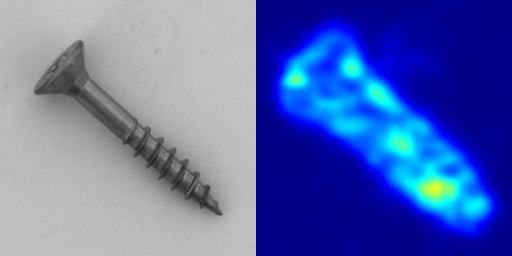

In [7]:
from IPython.display import Image, display
display(Image('eval/mvtec_screw/001.png'))